In [42]:
#Import Libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

In [60]:
#Load Dataset
df = pd.read_csv("amazon.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [61]:
#Dataset Overview and checking the missing values
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [98]:
#Data Cleaning
df["discounted_price"] = (
    df["discounted_price"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
)

df["discounted_price"] = pd.to_numeric(df["discounted_price"], errors="coerce")


df["actual_price"] = (
    df["actual_price"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
)

df["actual_price"] = pd.to_numeric(df["actual_price"], errors="coerce")


df["discount_percentage"] = (
    df["discount_percentage"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
)

df["discount_percentage"] = pd.to_numeric(df["discount_percentage"], errors="coerce")


df["rating_count"] = (
    df["rating_count"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
)

df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")

cols = ["discounted_price", "actual_price", "discount_percentage", "rating_count"]

df["rating"] = (
    df["rating"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')   # extract numeric value
)

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

In [99]:
# checking if data is clean or not cus im getting some errors
for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r"[^\d.]", "", regex=True)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")
print(df[[
    "discounted_price",
    "actual_price",
    "discount_percentage",
    "rating",
    "rating_count"
]].dtypes)

discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count           float64
dtype: object


In [84]:
#Creating SQl database
df = pd.read_csv("amazon.csv")

conn = sqlite3.connect("amazon.db")

df.to_sql("products", conn, if_exists="replace", index=False)

print("Database created!")

Database created!


In [85]:
# Checking table 
pd.read_sql("SELECT * FROM products LIMIT 5", conn)



,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [86]:
#total number of products
query = """
SELECT COUNT(*) as total_products
FROM products
"""

pd.read_sql(query, conn)

,total_products
0,1465


In [110]:
#Average Product Rating
query = """
SELECT AVG(rating) as avg_rating
FROM products
"""

pd.read_sql(query, conn)

,avg_rating
0,4.093788


In [101]:
#Highest Procust Rating
query = """
SELECT product_name, rating
FROM products
ORDER BY rating DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,product_name,rating
0,Eureka Forbes car Vac 100 Watts Powerful Sucti...,|
1,Syncwire LTG to USB Cable for Fast Charging Co...,5.0
2,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",5.0
3,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0
4,Swiffer Instant Electric Water Heater Faucet T...,4.8
5,"Oratech Coffee Frother electric, milk frother ...",4.8
6,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",4.8
7,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,4.7
8,Spigen EZ Fit Tempered Glass Screen Protector ...,4.7
9,"FIGMENT Handheld Milk Frother Rechargeable, 3-...",4.7


In [105]:
# Products with most reviews
query = """
SELECT product_name, rating_count
FROM products
ORDER BY CAST(REPLACE(rating_count, ',', '') AS INTEGER) DESC
LIMIT 10
"""

top10 = pd.read_sql(query, conn)
top10

,product_name,rating_count
0,AmazonBasics Flexible Premium HDMI Cable (Blac...,"4,26,973"
1,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...","4,26,973"
2,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...","4,26,973"
3,AmazonBasics Flexible Premium HDMI Cable (Blac...,"4,26,972"
4,boAt Bassheads 100 in Ear Wired Earphones with...,"3,63,713"
5,boAt Bassheads 100 in Ear Wired Earphones with...,"3,63,713"
6,boAt BassHeads 100 in-Ear Wired Headphones wit...,"3,63,711"
7,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...","3,13,836"
8,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...","3,13,836"
9,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...","3,13,832"


In [109]:
# Average Discount by Category
query = """
SELECT category,
       AVG(CAST(REPLACE(discount_percentage, '%', '') AS REAL)) AS avg_discount
FROM products
GROUP BY category
ORDER BY avg_discount DESC
"""

avg_discount_by_category = pd.read_sql(query, conn)
avg_discount_by_category

,category,avg_discount
0,Electronics|Mobiles&Accessories|MobileAccessor...,90.0
1,"Electronics|Headphones,Earbuds&Accessories|Ear...",90.0
2,Computers&Accessories|Accessories&Peripherals|...,90.0
3,"Electronics|Headphones,Earbuds&Accessories|Ada...",88.0
4,Computers&Accessories|Accessories&Peripherals|...,87.5
...,...,...
206,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,0.0
207,Home&Kitchen|CraftMaterials|PaintingMaterials,0.0
208,Home&Kitchen|CraftMaterials|DrawingMaterials|D...,0.0
209,Electronics|HomeAudio|MediaStreamingDevices|St...,0.0


In [107]:
# Cheapest Products
query = """
SELECT product_name, discounted_price
FROM products
ORDER BY CAST(REPLACE(REPLACE(discounted_price, '₹', ''), ',', '') AS REAL) ASC
LIMIT 10
"""

top_cheapest = pd.read_sql(query, conn)
top_cheapest

,product_name,discounted_price
0,GIZGA essentials Universal Silicone Keyboard P...,₹39
1,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,₹39
2,Inventis 5V 1.2W Portable Flexible USB LED Lig...,₹39
3,Classmate Octane Neon- Blue Gel Pens(Pack of 5...,₹50
4,FLiX (Beetel Flow USB to Micro USB PVC Data Sy...,₹57.89
5,Flix Micro Usb Cable For Smartphone (Black),₹59
6,FLiX (Beetel USB to Micro USB PVC Data Sync & ...,₹59
7,Flix Micro Usb Cable For Smartphone (Black),₹59
8,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,₹59
9,Flix Micro Usb Cable For Smartphone (Black),₹59


In [106]:
# Most Expensive Products
query = """
SELECT product_name, actual_price
FROM products
ORDER BY CAST(REPLACE(REPLACE(actual_price, '₹', ''), ',', '') AS REAL) DESC
LIMIT 10
"""

top_expensive = pd.read_sql(query, conn)
top_expensive

,product_name,actual_price
0,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,"₹1,39,900"
1,VU 164 cm (65 inches) The GloLED Series 4K Sma...,"₹85,000"
2,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,"₹79,990"
3,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,"₹75,990"
4,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...","₹74,999"
5,Samsung 138 cm (55 inches) Crystal 4K Neo Seri...,"₹70,900"
6,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,"₹69,999"
7,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,"₹69,999"
8,Samsung 138 cm (55 inches) Crystal 4K Series U...,"₹69,900"
9,VU 139 cm (55 inches) The GloLED Series 4K Sma...,"₹65,000"


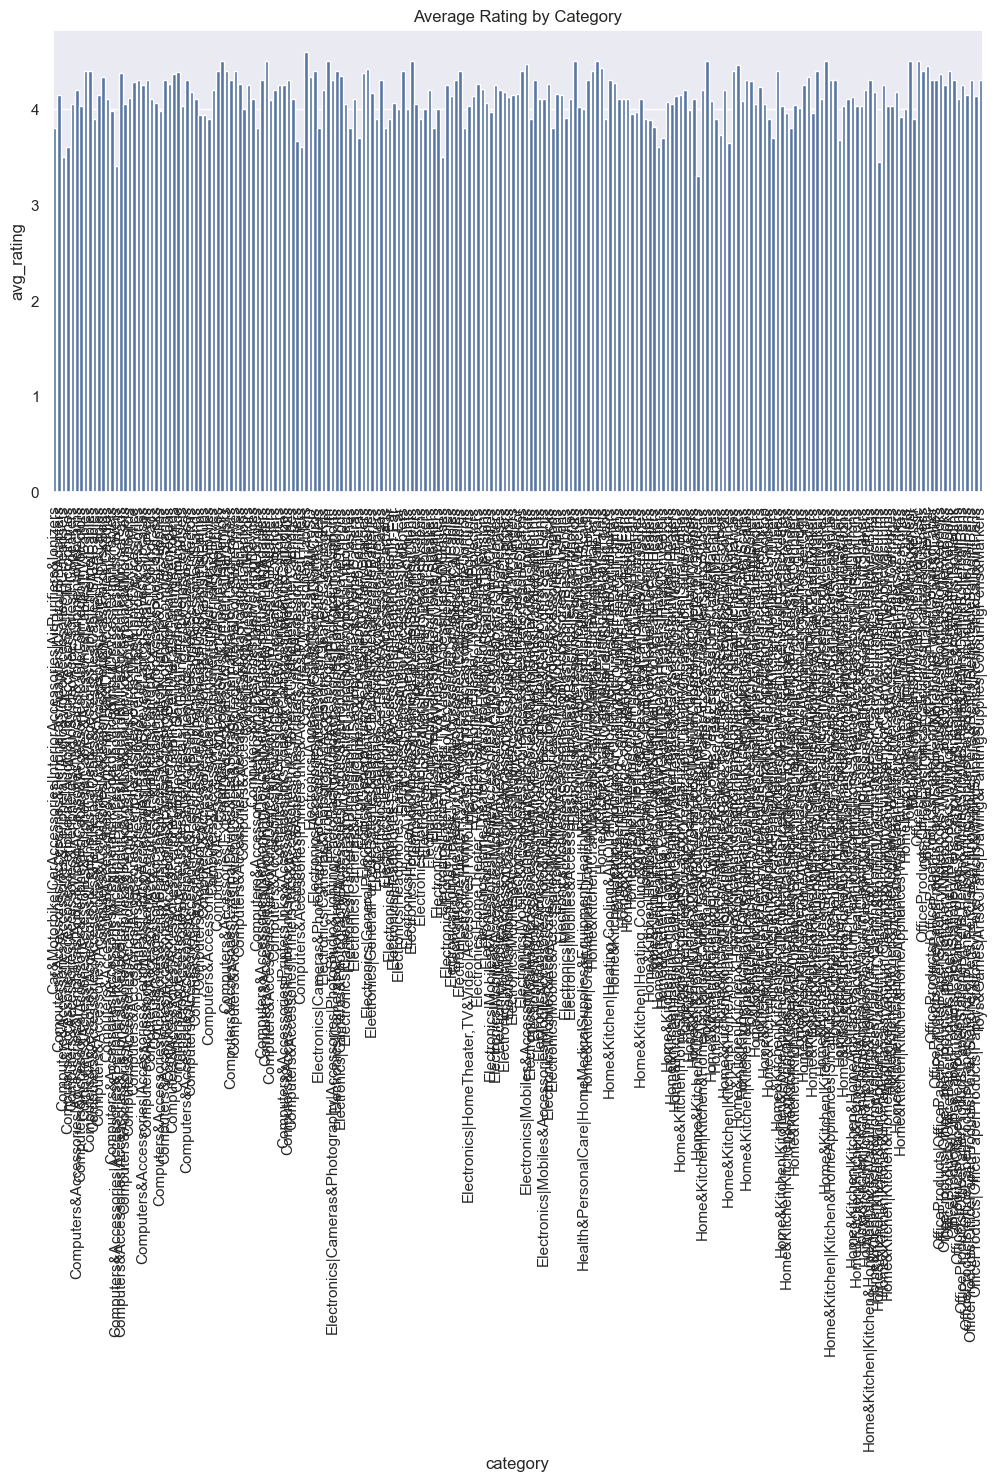

In [111]:
# Vistualization for avg rating by category 
query = """
SELECT category, AVG(rating) as avg_rating
FROM products
GROUP BY category
"""

result = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
sns.barplot(data=result, x="category", y="avg_rating")

plt.xticks(rotation=90)
plt.title("Average Rating by Category")

plt.show()

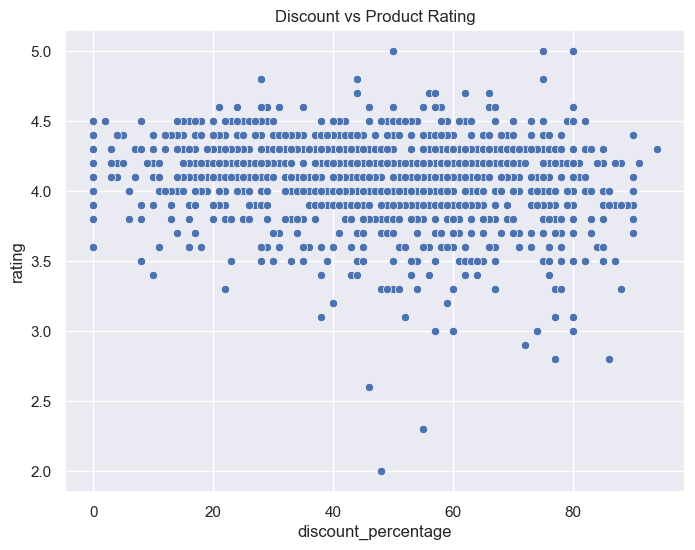

In [112]:
# Visualization — Discount vs Rating
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="discount_percentage",
    y="rating"
)

plt.title("Discount vs Product Rating")

plt.show()

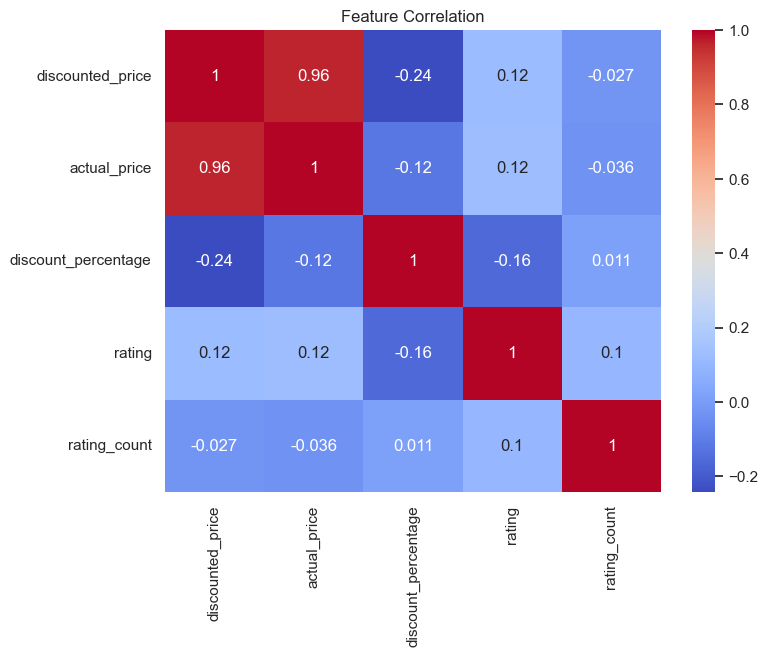

In [113]:
# Correlation Heatmap
numeric_df = df[[
    "discounted_price",
    "actual_price",
    "discount_percentage",
    "rating",
    "rating_count"
]]

numeric_df = numeric_df.dropna()

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

In [114]:
# Close SQL Connection
conn.close()